# Multi-task output visualisation

This notebook scans an array-job output directory and plots key outputs for each successfully completed task.

For each completed task (must contain both `details.yaml` and `idata.nc`), it displays:

1. Calibration (Figure 1 style from manuscript)
2. Posterior vs prior distributions
3. Diff outputs using `plot_diff_outputs()`
4. Four-panel projected trajectories for baseline vs `scenario_3`

In [ ]:
from pathlib import Path
from math import ceil
import re
import yaml

import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from IPython.display import display, Markdown

import tbh.plotting as pl
import tbh.runner_tools as rt
from tbh.model import get_tb_model
from tbh.paths import REPO_ROOT_PATH
from estival.model import BayesianCompartmentalModel

plt.style.use("ggplot")

In [ ]:
# Set the array-job output directory to scan

base_dir = REPO_ROOT_PATH / "remote_cluster" / "outputs" / "58975196_array_job_4"

if not base_dir.exists():
    raise FileNotFoundError(f"Directory not found: {base_dir}")

print("Scanning:", base_dir)

In [ ]:
task_dirs = sorted(
    [p for p in base_dir.iterdir() if p.is_dir()]
)

if not task_dirs:
    raise ValueError(f"No task folders found in {base_dir}")

records = []
for task_dir in task_dirs:
    files = [x for x in task_dir.iterdir() if x.is_file()]
    names = {f.name for f in files}

    has_idata = "idata.nc" in names
    has_details = "details.yaml" in names

    if len(files) == 0:
        status = "empty"
    elif has_details:
        status = "completed"
    elif has_idata:
        status = "partial"
    else:
        status = "failed"

    records.append({
        "task": task_dir.name,
        "task_path": task_dir,
        "n_files": len(files),
        "status": status,
    })

status_df = pd.DataFrame(records)
display(status_df[["task", "n_files", "status"]])
display(status_df["status"].value_counts().rename_axis("status").reset_index(name="count"))

completed_df = status_df.loc[status_df["status"] == "completed"].copy()
print(f"Completed tasks: {len(completed_df)}")

In [ ]:
config_map_path = base_dir / "task_config_map.yaml"
if not config_map_path.exists():
    raise FileNotFoundError(f"Config map not found: {config_map_path}")

with open(config_map_path, "r") as f:
    raw_task_config_map = yaml.safe_load(f)

config_source = raw_task_config_map.get("tasks", raw_task_config_map) if isinstance(raw_task_config_map, dict) else raw_task_config_map
task_to_config = config_source.get("task_to_config", {}) if isinstance(config_source, dict) else {}

def get_task_config(task_name):
    task_num = int(task_name.split("_")[1])
    return task_to_config.get(task_num, task_to_config.get(str(task_num)))

def short_config_label(task_cfg):
    if not isinstance(task_cfg, dict):
        return "cfg_unknown"

    rel_sus = task_cfg.get("rel_sus_unreachable", "na")
    reg = task_cfg.get("clinical_regression_rate", "na")
    return f"rel_sus_{rel_sus} reg_{reg}"

completed_df["task_config"] = completed_df["task"].apply(get_task_config)
completed_df["config_label"] = completed_df["task_config"].apply(short_config_label)
display(completed_df[["task", "config_label"]])

In [ ]:
def make_figure_1(uncertainty_df, bcm, colour="#B22222"):
    selected_outputs = [
        "pearl_posXreach_reachable_per100k",
        "cxr_posXreach_reachable_per100k",
        "perc_prev_subclinicalXreach_reachable",
        "perc_prev_infectiousXreach_reachable",
        "notifications",
    ]

    n_col = 3
    n_panels = len(selected_outputs) + 1
    n_row = ceil(n_panels / n_col)

    fig, axes = plt.subplots(n_row, n_col, figsize=(5 * n_col, 3.6 * n_row))
    axes = axes.flatten()

    for i, output in enumerate(selected_outputs):
        ax = axes[i]
        x_min = 1990 if output == "notifications" else 2010
        pl.plot_model_fit_with_uncertainty(ax, uncertainty_df, output, bcm, x_lim=(x_min, 2025), colour=colour)
        if i == 0:
            ax.legend()

    ax = axes[len(selected_outputs)]
    agegroups = ["3_9", "10", "15+", "18+"]
    model_median, model_low, model_high, observed, x_tick_labels = [], [], [], [], []

    for age in agegroups:
        output_name = f"tst_posXage_{age}Xreach_reachable_perc"
        year = bcm.targets[output_name].data.index[0]
        q = uncertainty_df[output_name].loc[year]
        obs = bcm.targets[output_name].data.iloc[0]

        model_median.append(q["0.5"])
        model_low.append(q["0.025"])
        model_high.append(q["0.975"])
        observed.append(obs)

        suffix = f" y.o.\n({year})"
        if age == "3_9":
            x_tick_labels.append("3-9" + suffix)
        elif age == "15+":
            x_tick_labels.append("15+" + suffix)
        else:
            x_tick_labels.append(f"{age}" + suffix)

    x = range(len(agegroups))
    ax.errorbar(
        [i - 0.06 for i in x],
        model_median,
        yerr=[
            [m - l for m, l in zip(model_median, model_low)],
            [h - m for h, m in zip(model_high, model_median)],
        ],
        fmt="D",
        color=colour,
        ecolor=colour,
        markersize=4,
        elinewidth=2.0,
        capsize=0,
        label="Model (median, 95% CI)",
    )
    ax.scatter([i + 0.06 for i in x], observed, color="black", s=15, zorder=5, label="Observed")
    ax.set_xticks(list(x))
    ax.set_xticklabels(x_tick_labels)
    ax.set_ylabel(pl.title_lookup["tst_posXreach_reachable_perc"])
    ax.grid(alpha=0.3)

    model_handle = mlines.Line2D([], [], color=colour, marker="D", markersize=4, linestyle="-", label="Model (median, 95% CI)")
    obs_handle = mlines.Line2D([], [], color="black", marker="o", linestyle="None", markersize=4, label="Observed")
    ax.legend(handles=[obs_handle, model_handle], frameon=False, loc="best")

    for j in range(n_panels, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig

In [ ]:
params, priors, tv_params = rt.get_parameters_and_priors()
intervention_scenarios = [sc.sc_id for sc in rt.SCENARIOS]
trajectory_outputs = [
    "tb_incidence_per100k",
    "viable_tbi_prevalence_perc",
    "tb_prevalence_per100k",
    "tb_mortality_per100k",
]

def resolve_task_names(task_selection, available_task_names):
    """
    Resolve task names from:
    - None: all available tasks
    - list/tuple/set of names (e.g. ["task_1", "task_6"])
    - list/tuple/set of ints (e.g. [1, 6])
    """
    if task_selection is None:
        return list(available_task_names)

    requested = []
    for item in task_selection:
        if isinstance(item, int):
            requested.append(f"task_{item}")
        else:
            requested.append(str(item))

    missing = [name for name in requested if name not in available_task_names]
    if missing:
        raise ValueError(f"Requested tasks not found in completed set: {missing}")

    return requested

def load_task_bundle(task_name):
    row_match = completed_df.loc[completed_df["task"] == task_name]
    if row_match.empty:
        raise ValueError(f"Task not found in completed_df: {task_name}")

    row = row_match.iloc[0]
    task_path = Path(row["task_path"])
    cfg_label = row["config_label"]

    required = [
        task_path / "idata.nc",
        task_path / "details.yaml",
        task_path / "uncertainty_df_baseline.parquet",
    ]
    missing = [p.name for p in required if not p.exists()]
    if missing:
        return {
            "task_name": task_name,
            "task_path": task_path,
            "cfg_label": cfg_label,
            "loaded": False,
            "missing": missing,
        }

    idata = az.from_netcdf(task_path / "idata.nc")

    with open(task_path / "details.yaml", "r") as f:
        docs = list(yaml.safe_load_all(f))

    model_config = docs[1] if len(docs) > 1 else {}
    analysis_config = docs[2] if len(docs) > 2 else {}
    if not isinstance(model_config, dict):
        model_config = {}
    if not isinstance(analysis_config, dict):
        analysis_config = {}

    model = get_tb_model(model_config, tv_params)
    bcm = BayesianCompartmentalModel(model, params, priors, rt.targets)

    available_unc = [
        p.name.replace("uncertainty_df_", "").replace(".parquet", "")
        for p in task_path.glob("uncertainty_df_*.parquet")
    ]
    unc_dfs = {
        sc: pd.read_parquet(task_path / f"uncertainty_df_{sc}.parquet")
        for sc in available_unc
    }

    available_diff = [
        p.name.replace("diff_quantiles_df_ref_baseline_", "").replace(".parquet", "")
        for p in task_path.glob("diff_quantiles_df_ref_baseline_*.parquet")
    ]
    diff_outputs_dfs = {
        sc: pd.read_parquet(task_path / f"diff_quantiles_df_ref_baseline_{sc}.parquet")
        for sc in available_diff
    }

    return {
        "task_name": task_name,
        "task_path": task_path,
        "cfg_label": cfg_label,
        "loaded": True,
        "idata": idata,
        "analysis_config": analysis_config,
        "bcm": bcm,
        "unc_dfs": unc_dfs,
        "diff_outputs_dfs": diff_outputs_dfs,
        "missing": [],
    }

# Task selection for data loading. Set to None to load all completed tasks.
tasks_to_load = None
# Example: tasks_to_load = [1, 6, 10] or ["task_1", "task_6"]

available_task_names = completed_df["task"].tolist()
selected_task_names = resolve_task_names(tasks_to_load, available_task_names)

task_bundles = {}
for task_name in selected_task_names:
    task_bundles[task_name] = load_task_bundle(task_name)

bundle_summary = pd.DataFrame([
    {
        "task": b["task_name"],
        "config": b["cfg_label"],
        "loaded": b["loaded"],
        "missing": ", ".join(b["missing"]) if b["missing"] else "",
    }
    for b in task_bundles.values()
])

display(bundle_summary)

loaded_task_names = [name for name, b in task_bundles.items() if b["loaded"]]
print(f"Loaded tasks: {len(loaded_task_names)} / {len(task_bundles)}")

In [ ]:
# Plot type 1: Calibration (Figure 1 style)
# Set to None for all loaded tasks, or provide a list like [1, 6] or ["task_1", "task_6"]
calibration_plot_tasks = [1,3]

for task_name in resolve_task_names(calibration_plot_tasks, loaded_task_names):
    bundle = task_bundles[task_name]
    cfg_label = bundle["cfg_label"]
    unc_dfs = bundle["unc_dfs"]
    bcm = bundle["bcm"]

    display(Markdown("---"))
    display(Markdown(f"### Calibration: {task_name}"))
    display(Markdown(f"Config: `{cfg_label}`"))

    if "baseline" in unc_dfs:
        fig = make_figure_1(unc_dfs["baseline"], bcm)
        fig.suptitle(f"{task_name} | {cfg_label}", y=1.02, fontsize=12)
        display(fig)
        plt.close(fig)
    else:
        display(Markdown("Calibration skipped: baseline uncertainty file missing."))

---

### Posterior vs prior: task_3

Config: `rel_sus_2.0 reg_0.5`

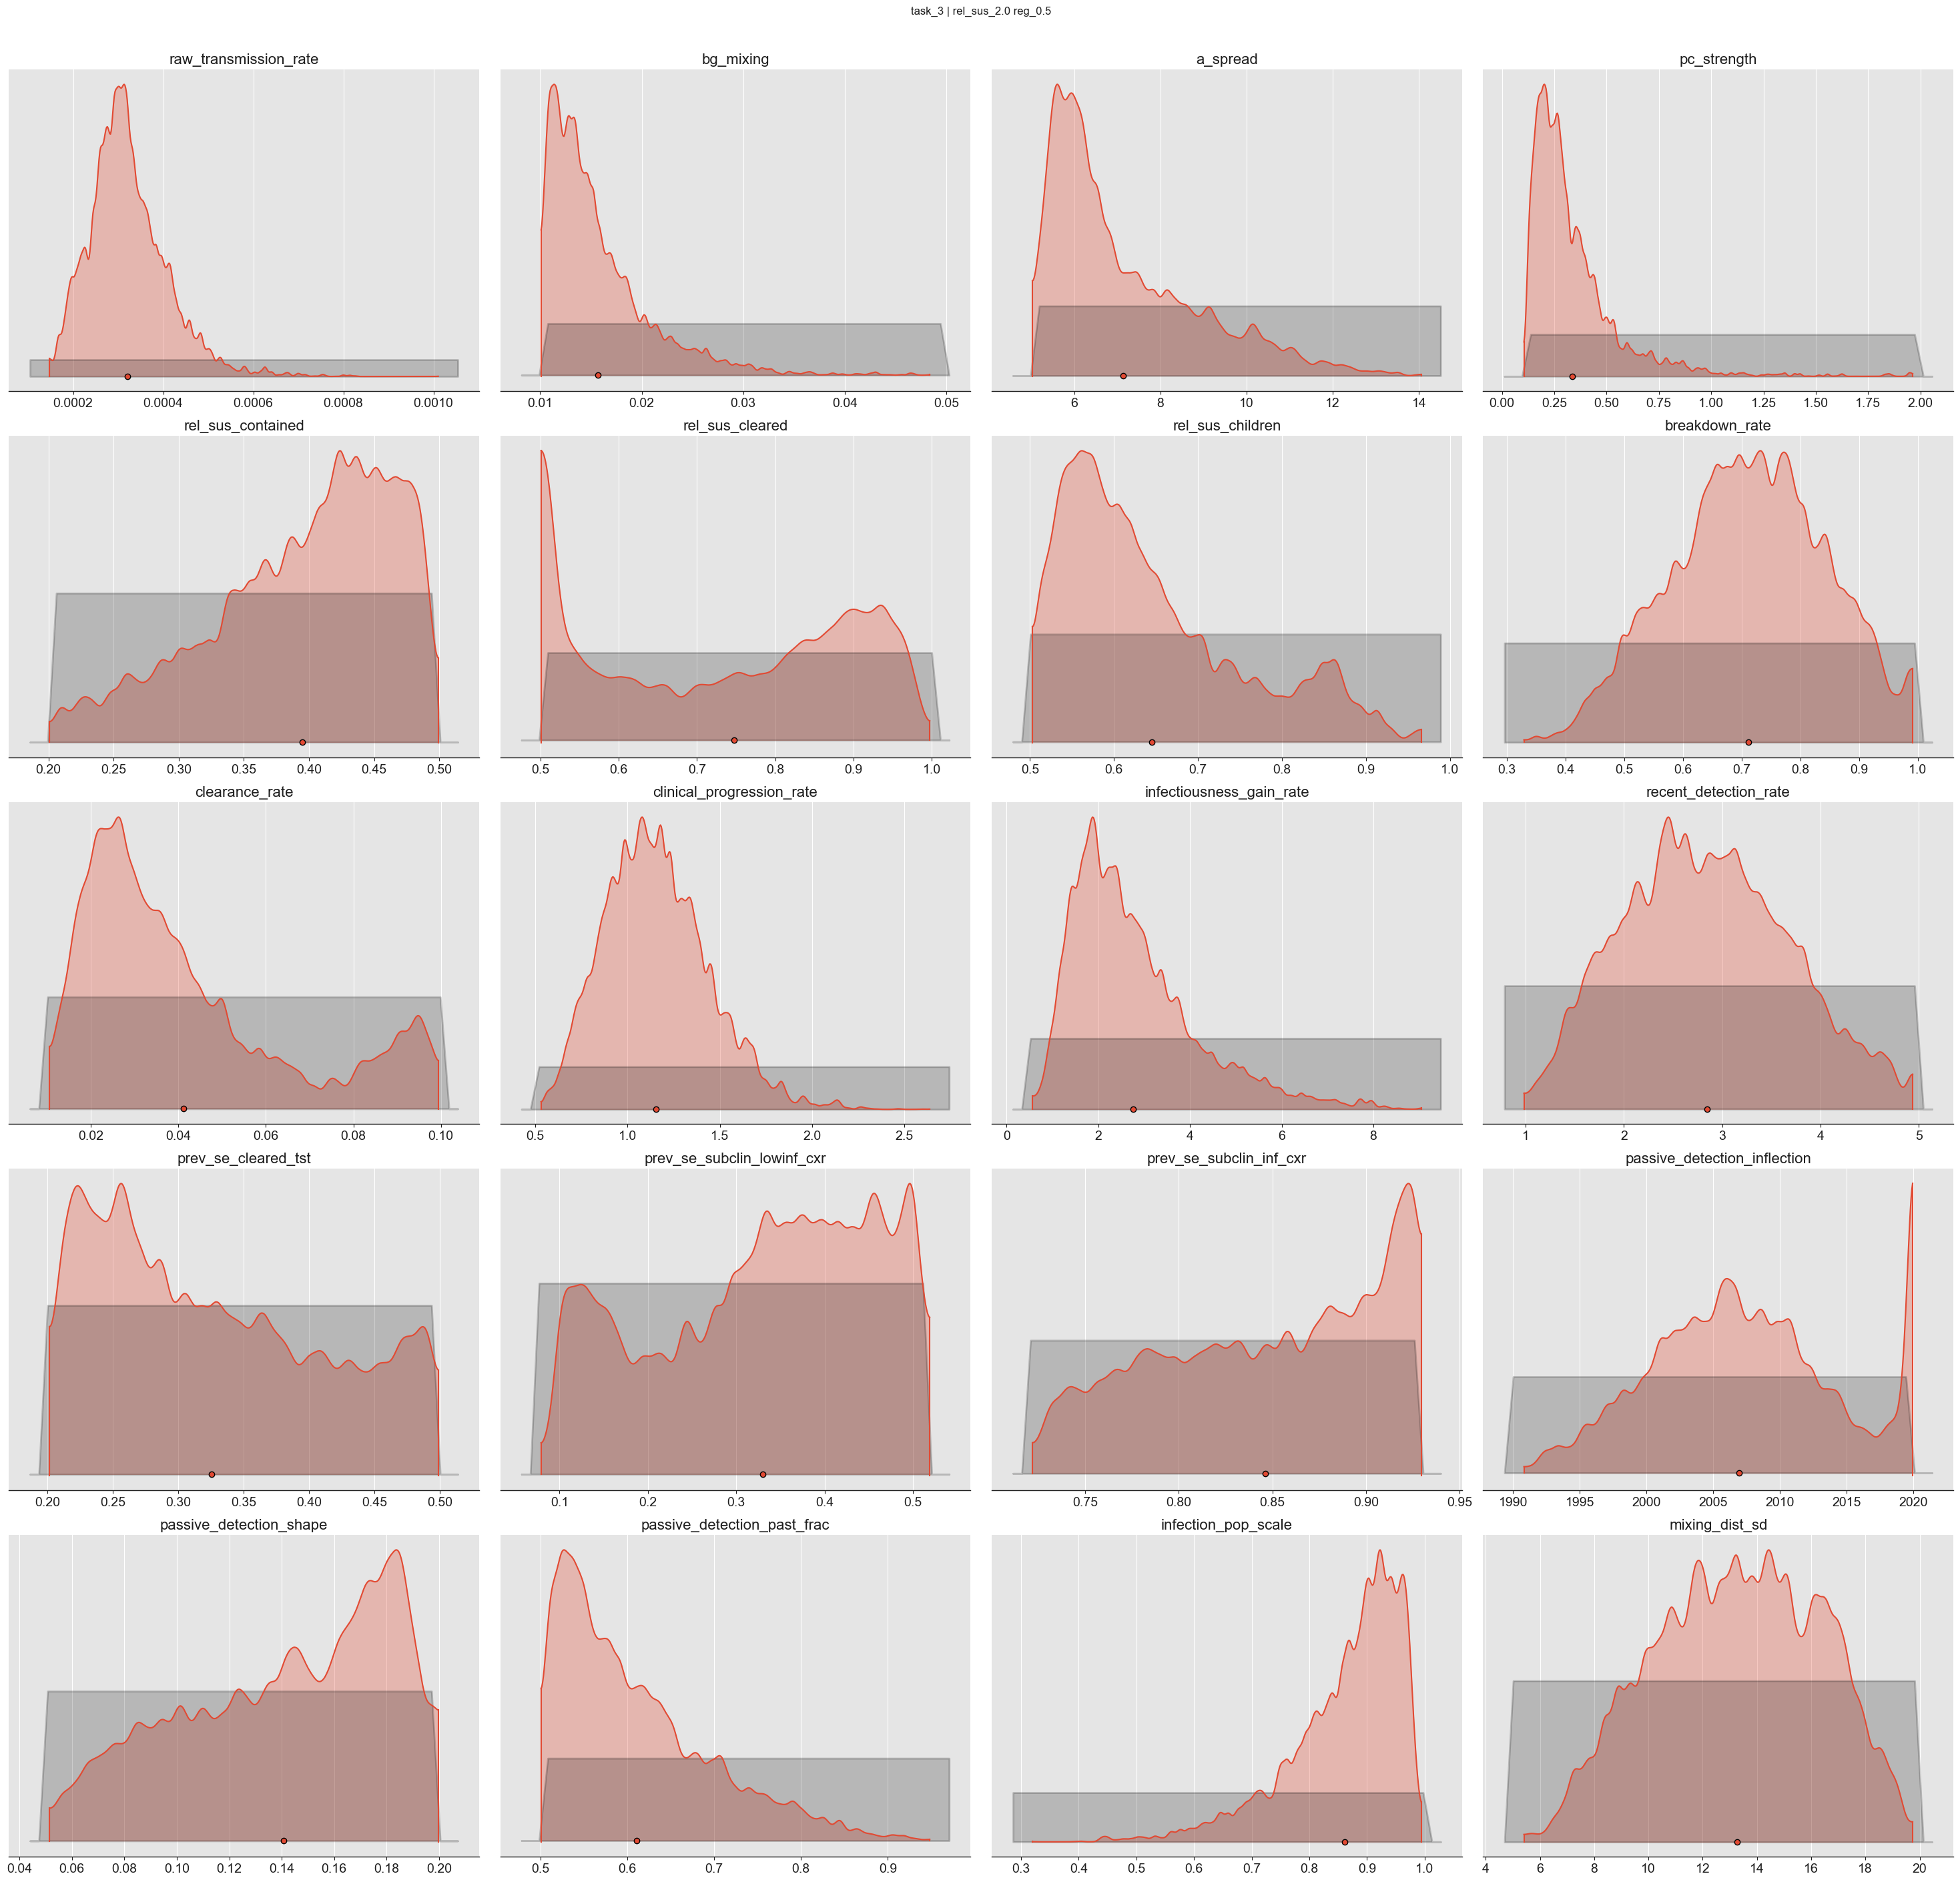

In [17]:
# Plot type 2: Posterior vs prior distributions
# Set to None for all loaded tasks, or provide a list like [1, 6] or ["task_1", "task_6"]
posterior_plot_tasks = [3]

for task_name in resolve_task_names(posterior_plot_tasks, loaded_task_names):
    bundle = task_bundles[task_name]
    cfg_label = bundle["cfg_label"]
    bcm = bundle["bcm"]
    idata = bundle["idata"]
    analysis_config = bundle["analysis_config"]

    burn_in = analysis_config.get("burn_in", 0)

    display(Markdown("---"))
    display(Markdown(f"### Posterior vs prior: {task_name}"))
    display(Markdown(f"Config: `{cfg_label}`"))

    fig = pl.plot_post_prior_comparison(
        idata,
        burn_in,
        req_vars=list(bcm.priors.keys()),
        priors=list(bcm.priors.values()),
    )
    fig.suptitle(f"{task_name} | {cfg_label}", y=1.02, fontsize=12)
    display(fig)
    plt.close(fig)

---

### Parameter traces by chain: task_15

Config: `rel_sus_2.0 reg_4.0`

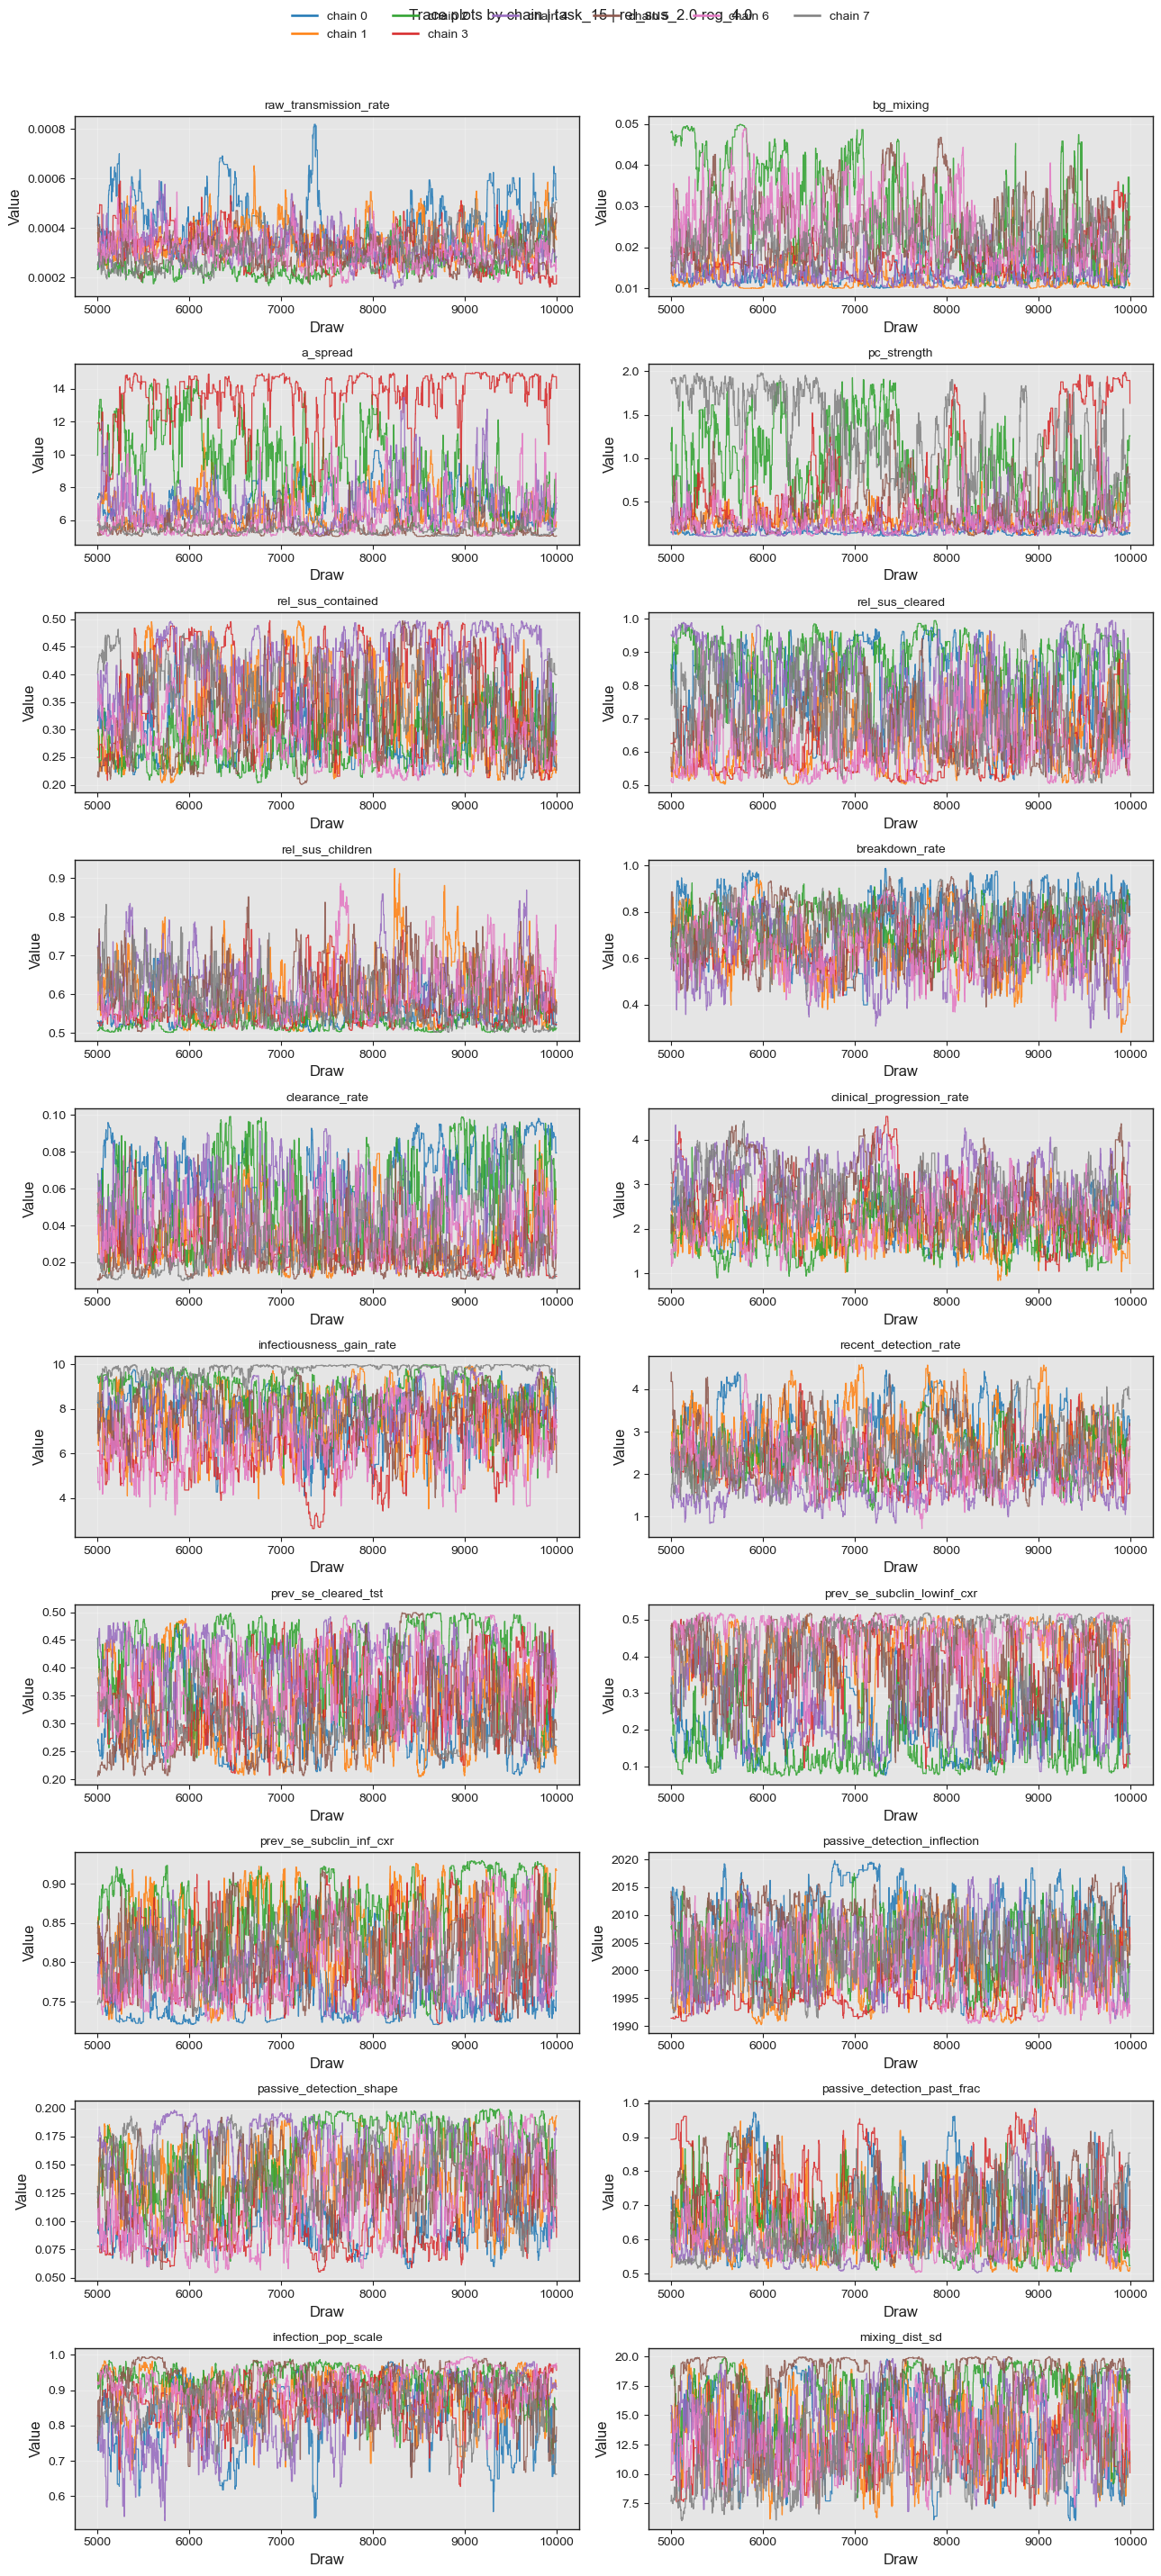

In [19]:
# Plot type 2b: Parameter traces by chain for one selected task
# Set selected_trace_task to an int (e.g. 6) or a task name (e.g. "task_6")
selected_trace_task = 15

trace_task_name = resolve_task_names([selected_trace_task], loaded_task_names)[0]
bundle = task_bundles[trace_task_name]

cfg_label = bundle["cfg_label"]
bcm = bundle["bcm"]
idata = bundle["idata"]
analysis_config = bundle["analysis_config"]

burn_in = analysis_config.get("burn_in", 0)
posterior = idata.posterior
if burn_in > 0 and "draw" in posterior.dims:
    posterior = posterior.isel(draw=slice(burn_in, None))

trace_params = [p for p in bcm.priors.keys() if p in posterior.data_vars]
if not trace_params:
    raise ValueError(f"No prior parameters found in posterior for {trace_task_name}.")

display(Markdown("---"))
display(Markdown(f"### Parameter traces by chain: {trace_task_name}"))
display(Markdown(f"Config: `{cfg_label}`"))

n_col = 2
n_row = ceil(len(trace_params) / n_col)
fig, axes = plt.subplots(n_row, n_col, figsize=(6.5 * n_col, 2.8 * n_row), sharex=False)

if hasattr(axes, "flatten"):
    axes = axes.flatten()
else:
    axes = [axes]

# Fix one color per chain across all parameter panels.
chain_ids = sorted(list(posterior[trace_params[0]]["chain"].values))
base_colors = list(plt.cm.tab10.colors) + list(plt.cm.Set2.colors)
if len(chain_ids) > len(base_colors):
    repeats = ceil(len(chain_ids) / len(base_colors))
    base_colors = (base_colors * repeats)[:len(chain_ids)]
chain_color_map = {chain_id: base_colors[i] for i, chain_id in enumerate(chain_ids)}

for i, param_name in enumerate(trace_params):
    ax = axes[i]
    da = posterior[param_name]

    # For non-scalar parameters, average over extra dims to keep one trace per chain.
    extra_dims = [d for d in da.dims if d not in ["chain", "draw"]]
    if extra_dims:
        da = da.mean(dim=extra_dims)

    draw_values = da["draw"].values
    for chain_value in chain_ids:
        chain_series = da.sel(chain=chain_value).values
        ax.plot(
            draw_values,
            chain_series,
            linewidth=0.9,
            alpha=0.85,
            color=chain_color_map[chain_value],
        )

    title_suffix = " (mean over extra dims)" if extra_dims else ""
    ax.set_title(f"{param_name}{title_suffix}", fontsize=10)
    ax.set_xlabel("Draw")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

for j in range(len(trace_params), len(axes)):
    fig.delaxes(axes[j])

legend_handles = [
    mlines.Line2D([], [], color=chain_color_map[c], linewidth=1.8, label=f"chain {c}")
    for c in chain_ids
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=min(6, len(chain_ids)),
    frameon=False,
)

fig.suptitle(f"Trace plots by chain | {trace_task_name} | {cfg_label}", y=1.02, fontsize=12)
fig.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
# Convergence check: R-hat after burn-in across selected tasks
# Set to None for all loaded tasks, or provide a list like [1, 6] or ["task_1", "task_6"]
rhat_tasks = None

selected_rhat_tasks = resolve_task_names(rhat_tasks, loaded_task_names)

rhat_task_rows = []
rhat_param_rows = []

def extract_rhat_values(rhat_obj):
    """Return flattened numeric values from ArviZ rhat output (DataArray or Dataset)."""
    # xarray.Dataset -> convert to DataArray first
    if hasattr(rhat_obj, "to_array"):
        arr = rhat_obj.to_array().values
    else:
        arr = rhat_obj.values

    vals = pd.Series(arr.ravel()).dropna()
    return vals

for task_name in selected_rhat_tasks:
    bundle = task_bundles[task_name]
    cfg_label = bundle["cfg_label"]
    bcm = bundle["bcm"]
    idata = bundle["idata"]
    analysis_config = bundle["analysis_config"]

    burn_in = int(analysis_config.get("burn_in", 0))
    posterior = idata.posterior
    if burn_in > 0 and "draw" in posterior.dims:
        posterior = posterior.isel(draw=slice(burn_in, None))

    if "chain" not in posterior.dims or "draw" not in posterior.dims:
        rhat_task_rows.append({
            "task": task_name,
            "config": cfg_label,
            "burn_in": burn_in,
            "n_params_evaluated": 0,
            "max_rhat": float("nan"),
            "n_params_rhat_gt_1.01": 0,
            "n_params_rhat_gt_1.05": 0,
            "status": "missing chain/draw dims",
        })
        continue

    trace_params = [p for p in bcm.priors.keys() if p in posterior.data_vars]
    param_max_rhats = []

    for param_name in trace_params:
        try:
            rhat_obj = az.rhat(posterior[[param_name]])
            vals = extract_rhat_values(rhat_obj)
            if vals.empty:
                continue

            param_max = float(vals.max())
            param_mean = float(vals.mean())
            param_max_rhats.append(param_max)

            rhat_param_rows.append({
                "task": task_name,
                "config": cfg_label,
                "parameter": param_name,
                "max_rhat": param_max,
                "mean_rhat": param_mean,
                "n_elements": int(vals.size),
                "burn_in": burn_in,
            })
        except Exception as exc:
            rhat_param_rows.append({
                "task": task_name,
                "config": cfg_label,
                "parameter": param_name,
                "max_rhat": float("nan"),
                "mean_rhat": float("nan"),
                "n_elements": 0,
                "burn_in": burn_in,
                "error": str(exc),
            })

    if param_max_rhats:
        max_rhat_task = float(max(param_max_rhats))
        n_gt_101 = int(sum(v > 1.01 for v in param_max_rhats))
        n_gt_105 = int(sum(v > 1.05 for v in param_max_rhats))
        status = "ok"
    else:
        max_rhat_task = float("nan")
        n_gt_101 = 0
        n_gt_105 = 0
        status = "no evaluable parameters"

    rhat_task_rows.append({
        "task": task_name,
        "config": cfg_label,
        "burn_in": burn_in,
        "n_params_evaluated": len(param_max_rhats),
        "max_rhat": max_rhat_task,
        "n_params_rhat_gt_1.01": n_gt_101,
        "n_params_rhat_gt_1.05": n_gt_105,
        "status": status,
    })

rhat_task_df = pd.DataFrame(rhat_task_rows).sort_values(["max_rhat", "task"], ascending=[False, True], na_position="last")
rhat_param_df = pd.DataFrame(rhat_param_rows).sort_values(["task", "max_rhat"], ascending=[True, False], na_position="last")

display(Markdown("---"))
display(Markdown("### R-hat summary by task (after burn-in)"))
display(rhat_task_df)

display(Markdown("### Parameter-level R-hat details"))
display(rhat_param_df)

if not rhat_task_df.empty and rhat_task_df["max_rhat"].notna().any():
    worst = rhat_task_df.loc[rhat_task_df["max_rhat"].idxmax()]
    print(
        f"Worst max R-hat: {worst['task']} | max_rhat={worst['max_rhat']:.4f} "
        f"(burn_in={worst['burn_in']})"
    )
else:
    print("No finite R-hat values computed for the selected tasks.")

---

### R-hat summary by task (after burn-in)

,task,config,burn_in,n_params_evaluated,max_rhat,n_params_rhat_gt_1.01,n_params_rhat_gt_1.05,status
0,task_1,rel_sus_1.0 reg_0.5,5000,0,NaN,0,0,no evaluable parameters
1,task_10,rel_sus_1.5 reg_2.0,5000,0,NaN,0,0,no evaluable parameters
2,task_11,rel_sus_2.0 reg_2.0,5000,0,NaN,0,0,no evaluable parameters
3,task_12,rel_sus_3.0 reg_2.0,5000,0,NaN,0,0,no evaluable parameters
4,task_13,rel_sus_1.0 reg_4.0,5000,0,NaN,0,0,no evaluable parameters
5,task_14,rel_sus_1.5 reg_4.0,5000,0,NaN,0,0,no evaluable parameters
6,task_15,rel_sus_2.0 reg_4.0,5000,0,NaN,0,0,no evaluable parameters
7,task_16,rel_sus_3.0 reg_4.0,5000,0,NaN,0,0,no evaluable parameters
8,task_2,rel_sus_1.5 reg_0.5,5000,0,NaN,0,0,no evaluable parameters
9,task_3,rel_sus_2.0 reg_0.5,5000,0,NaN,0,0,no evaluable parameters


### Parameter-level R-hat details

,task,config,parameter,max_rhat,mean_rhat,n_elements,burn_in,error
0,task_1,rel_sus_1.0 reg_0.5,raw_transmission_rate,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
1,task_1,rel_sus_1.0 reg_0.5,bg_mixing,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
2,task_1,rel_sus_1.0 reg_0.5,a_spread,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
3,task_1,rel_sus_1.0 reg_0.5,pc_strength,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
4,task_1,rel_sus_1.0 reg_0.5,rel_sus_contained,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
...,...,...,...,...,...,...,...,...
315,task_9,rel_sus_1.0 reg_2.0,passive_detection_inflection,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
316,task_9,rel_sus_1.0 reg_2.0,passive_detection_shape,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
317,task_9,rel_sus_1.0 reg_2.0,passive_detection_past_frac,NaN,NaN,0,5000,'function' object has no attribute 'ravel'
318,task_9,rel_sus_1.0 reg_2.0,infection_pop_scale,NaN,NaN,0,5000,'function' object has no attribute 'ravel'


Worst max R-hat: task_1 | max_rhat=nan (burn_in=5000)


In [ ]:
# Plot type 3: Diff outputs from plot_diff_outputs()
# Set to None for all loaded tasks, or provide a list like [1, 6] or ["task_1", "task_6"]
diff_plot_tasks = None

diff_outputs_to_plot = ["TB_averted_relative", "deaths_averted_relative"]

for task_name in resolve_task_names(diff_plot_tasks, loaded_task_names):
    bundle = task_bundles[task_name]
    cfg_label = bundle["cfg_label"]
    diff_outputs_dfs = bundle["diff_outputs_dfs"]

    display(Markdown("---"))
    display(Markdown(f"### Diff outputs: {task_name}"))
    display(Markdown(f"Config: `{cfg_label}`"))

    scenarios_for_diff = [sc for sc in intervention_scenarios if sc in diff_outputs_dfs]
    if not scenarios_for_diff:
        display(Markdown("Diff outputs skipped: no diff parquet files found."))
        continue

    for output in diff_outputs_to_plot:
        fig, ax = plt.subplots(1, 1, figsize=(0.6 * len(scenarios_for_diff), 4.0))
        pl.plot_diff_outputs(ax, diff_outputs_dfs, output, scenarios_for_diff)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        ax.grid(axis="y", linestyle="-", linewidth=0.7, alpha=0.4)
        fig.suptitle(f"{task_name} | {cfg_label}", y=1.02, fontsize=12)
        fig.tight_layout()
        display(fig)
        plt.close(fig)

In [ ]:
# Plot type 4: Four-panel projected trajectories (baseline vs scenario_3)
# Set to None for all loaded tasks, or provide a list like [1, 6] or ["task_1", "task_6"]
trajectory_plot_tasks = None

for task_name in resolve_task_names(trajectory_plot_tasks, loaded_task_names):
    bundle = task_bundles[task_name]
    cfg_label = bundle["cfg_label"]
    unc_dfs = bundle["unc_dfs"]

    display(Markdown("---"))
    display(Markdown(f"### Trajectories: {task_name}"))
    display(Markdown(f"Config: `{cfg_label}`"))

    if "baseline" not in unc_dfs or "scenario_3" not in unc_dfs:
        display(Markdown("Trajectories skipped: baseline or scenario_3 uncertainty file missing."))
        continue

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
    axes = axes.flatten()

    for ax, output in zip(axes, trajectory_outputs):
        pl.plot_two_scenarios(
            ax,
            unc_dfs,
            output,
            scenarios=["baseline", "scenario_3"],
            xlim=(2020, 2035),
            include_unc=True,
            ylab_fontsize=9,
        )
        ax.set_title(pl.title_lookup.get(output, output), fontsize=10)

    fig.suptitle(f"{task_name} | {cfg_label}", y=1.02, fontsize=12)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

In [ ]:
# Proportion of TB incidence from unreachable group:
# compare 2026 vs 2028 for rel_sus values at clinical_regression_rate = 1.0

import numpy as np

scenario = "scenario_3"

years_to_plot = [2026, 2028]
target_rel_sus_values = [1.0, 1.5, 2.0, 3.0]
target_reg = 1.0
output_name = "prop_tb_incidenceXreach_unreachable"

rows = []

for _, row in completed_df.iterrows():
    task_path = Path(row["task_path"])
    task_cfg = row.get("task_config", {})

    if not isinstance(task_cfg, dict):
        continue

    rel_sus = pd.to_numeric(task_cfg.get("rel_sus_unreachable"), errors="coerce")
    reg = pd.to_numeric(task_cfg.get("clinical_regression_rate"), errors="coerce")

    if pd.isna(rel_sus) or pd.isna(reg):
        continue
    if not np.isclose(reg, target_reg):
        continue
    if rel_sus not in target_rel_sus_values:
        continue

    unc_file = task_path / f"uncertainty_df_{scenario}.parquet"
    if not unc_file.exists():
        continue

    unc_df = pd.read_parquet(unc_file)
    if output_name not in unc_df.columns:
        continue

    for yr in years_to_plot:
        if yr not in unc_df.index:
            continue

        q = unc_df[output_name].loc[yr]

        median = q["0.5"] if "0.5" in q.index else q[0.5]
        low = q["0.025"] if "0.025" in q.index else q[0.025]
        high = q["0.975"] if "0.975" in q.index else q[0.975]

        rows.append(
            {
                "rel_sus_unreachable": float(rel_sus),
                "year": int(yr),
                "median_pct": 100.0 * float(median),
                "low_pct": 100.0 * float(low),
                "high_pct": 100.0 * float(high),
            }
        )

plot_df = pd.DataFrame(rows)

if plot_df.empty:
    raise ValueError(
        "No data found for reg=1.0 and requested rel_sus values in baseline uncertainty parquet files."
    )

# Keep one row per rel_sus-year pair in case of duplicates
plot_df = (
    plot_df.groupby(["rel_sus_unreachable", "year"], as_index=False)
    [["median_pct", "low_pct", "high_pct"]]
    .median()
)

plot_df = plot_df.sort_values(["rel_sus_unreachable", "year"]).reset_index(drop=True)

display(plot_df)

# Side-by-side bar plot with uncertainty bars
year_colors = {2026: "#EF8775", 2028: "#b43232"}
fig, ax = plt.subplots(figsize=(8.8, 5.2))

x = np.arange(len(target_rel_sus_values), dtype=float)
bar_width = 0.35

year_offsets = {
    years_to_plot[0]: -bar_width / 2.0,
    years_to_plot[1]: bar_width / 2.0,
}

leg_label ={2026: "before screening", 2028: "after screening"}

for yr in years_to_plot:
    sub = (
        plot_df.loc[plot_df["year"] == yr]
        .set_index("rel_sus_unreachable")
        .reindex(target_rel_sus_values)
        .reset_index()
    )

    y = sub["median_pct"].to_numpy()
    y_low = sub["low_pct"].to_numpy()
    y_high = sub["high_pct"].to_numpy()

    x_pos = x + year_offsets[yr]

    ax.bar(
        x_pos,
        y,
        width=bar_width,
        color=year_colors.get(yr, "#333333"),
        alpha=0.9,
        label=leg_label[yr],
        zorder=2,
    )
    ax.errorbar(
        x_pos,
        y,
        yerr=[y - y_low, y_high - y],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=3,
        zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.1f}" for v in target_rel_sus_values])
ax.set_xlabel("Relative susceptibility among the unreachable")
ax.set_ylabel("% of total TB incidence from the 15% unreachable")
# ax.set_title("Unreachable contribution to TB incidence: 2026 vs 2028 (reg = 1.0)")
ax.grid(axis="y", alpha=0.35, zorder=1)
ax.legend(frameon=False)

fig.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
sc_id_list = [3]

for sc_id in sc_id_list:

    # Extract scenario_3 diff data across all completed tasks
    scenario_3_data = []

    for _, row in completed_df.iterrows():
        task_name = row["task"]
        task_path = Path(row["task_path"])
        task_cfg = row.get("task_config", {})

        diff_file = task_path / f"diff_quantiles_df_ref_baseline_scenario_{sc_id}.parquet"
        if diff_file.exists():
            df_diff = pd.read_parquet(diff_file)
            scenario_3_data.append({
                "task": task_name,
                "rel_sus_unreachable": task_cfg.get("rel_sus_unreachable") if isinstance(task_cfg, dict) else None,
                "clinical_regression_rate": task_cfg.get("clinical_regression_rate") if isinstance(task_cfg, dict) else None,
                "TB_averted_relative": df_diff.loc[0.5, "TB_averted_relative"],
                "TB_averted_relative_low": df_diff.loc[0.025, "TB_averted_relative"],
                "TB_averted_relative_high": df_diff.loc[0.975, "TB_averted_relative"],
            })

    scenario_3_df = pd.DataFrame(scenario_3_data)

    # Ensure numeric and sort to create 4-point groups by regression rate
    for col in [
        "rel_sus_unreachable",
        "clinical_regression_rate",
        "TB_averted_relative",
        "TB_averted_relative_low",
        "TB_averted_relative_high",
    ]:
        scenario_3_df[col] = pd.to_numeric(scenario_3_df[col], errors="coerce")

    scenario_3_df = scenario_3_df.dropna(
        subset=[
            "rel_sus_unreachable",
            "clinical_regression_rate",
            "TB_averted_relative",
            "TB_averted_relative_low",
            "TB_averted_relative_high",
        ]
    ).copy()

    scenario_3_df = scenario_3_df.sort_values(
        ["clinical_regression_rate", "rel_sus_unreachable"]
    ).reset_index(drop=True)
    scenario_3_df["x"] = range(len(scenario_3_df))

    # Lancet-style typography and consistent text color across all elements
    text_color = "#1f1f1f"
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
        "text.color": text_color,
        "axes.labelcolor": text_color,
        "axes.titlecolor": text_color,
        "xtick.color": text_color,
        "ytick.color": text_color,
        "axes.edgecolor": text_color,
    })

    # Edit this palette to change colors by relative susceptibility value
    rel_sus_palette = {
        1.0: "#127624",
        1.5: "#094fa5",
        2.0: "#6d32a4",
        3.0: "#a81334",
    }
    default_rel_sus_color = "#7f7f7f"

    # Plot
    fig, ax = plt.subplots(figsize=(13, 6.5))

    # Draw one series per rel_sus value: dots, error bars, and linking line share color
    rel_sus_values = sorted(scenario_3_df["rel_sus_unreachable"].unique())
    for rel_sus in rel_sus_values:
        sub = scenario_3_df.loc[
            scenario_3_df["rel_sus_unreachable"] == rel_sus
        ].sort_values("x")

        xs = sub["x"].to_numpy()
        y = 100.0 * sub["TB_averted_relative"].to_numpy()
        y_low = 100.0 * sub["TB_averted_relative_low"].to_numpy()
        y_high = 100.0 * sub["TB_averted_relative_high"].to_numpy()

        series_color = rel_sus_palette.get(float(rel_sus), default_rel_sus_color)

        ax.errorbar(
            xs,
            y,
            yerr=[y - y_low, y_high - y],
            fmt="o",
            color=series_color,
            ecolor=series_color,
            markersize=8,
            elinewidth=2.0,
            capsize=5,
            zorder=3,
            label=f"rel_sus = {rel_sus:.1f}",
        )
        if len(xs) > 1:
            ax.plot(xs, y, color=series_color, linewidth=0.5, alpha=0.9, zorder=2)

    # Vertical separators after datapoints 4, 8, and 12 (1-based indexing)
    for sep in [3.5, 7.5, 11.5]:
        if sep < len(scenario_3_df) - 0.5:
            ax.axvline(sep, color="0.5", linestyle="--", linewidth=1.0, alpha=0.8, zorder=1)

    # Simplified x labels: relative susceptibility only
    x_all = scenario_3_df["x"].to_numpy()
    ax.set_xticks(x_all)
    ax.set_xticklabels([f"{v:.1f}" for v in scenario_3_df["rel_sus_unreachable"]], rotation=0)
    ax.set_xlabel("Relative susceptibility (unreachable)")
    ax.set_ylabel("TB episodes averted (relative %)")
    ax.grid(axis="y", linestyle="-", linewidth=0.7, alpha=0.4)

    # Group labels for clinical regression rate
    group_size = 4
    reg_values = scenario_3_df["clinical_regression_rate"].drop_duplicates().tolist()
    for i, reg in enumerate(reg_values):
        start = i * group_size
        end = min(start + group_size - 1, len(scenario_3_df) - 1)
        if start <= end:
            center = (start + end) / 2.0
            ax.text(
                center,
                1.03,
                f"TB spectrum regression rate = {reg:.1f} /y",
                ha="center",
                va="bottom",
                transform=ax.get_xaxis_transform(),
                fontsize=10,
                color=text_color,
            )

    fig.tight_layout()
    display(fig)
    plt.close(fig)

In [ ]:
# Two-panel posterior comparison at fixed rel_sus = 1.5
# Panel a: posterior of clinical_progression_rate by clinical_regression_rate
# Panel b: posterior of infectiousness parameter by infectiousness_loss_rate

import itertools

target_rel_sus = 1.5
panel_a_var = "clinical_progression_rate"
panel_b_candidates = ["infectiousness_loss_rate", "infectiousness_gain_rate"]

records = []
panel_b_var_detected = None

for _, row in completed_df.iterrows():
    task_path = Path(row["task_path"])
    task_cfg = row.get("task_config", {})

    if not isinstance(task_cfg, dict):
        continue

    rel_sus = pd.to_numeric(task_cfg.get("rel_sus_unreachable"), errors="coerce")
    reg_rate = pd.to_numeric(task_cfg.get("clinical_regression_rate"), errors="coerce")
    inf_loss_rate = pd.to_numeric(task_cfg.get("infectiousness_loss_rate"), errors="coerce")

    if pd.isna(rel_sus) or not np.isclose(rel_sus, target_rel_sus):
        continue

    idata_path = task_path / "idata.nc"
    if not idata_path.exists():
        continue

    idata = az.from_netcdf(idata_path)

    burn_in = 0
    details_path = task_path / "details.yaml"
    if details_path.exists():
        with open(details_path, "r") as f:
            docs = list(yaml.safe_load_all(f))
        if len(docs) > 2 and isinstance(docs[2], dict):
            burn_in = int(docs[2].get("burn_in", 0))

    posterior = idata.posterior
    if burn_in > 0 and "draw" in posterior.dims:
        posterior = posterior.isel(draw=slice(burn_in, None))

    if panel_a_var not in posterior.data_vars:
        continue

    panel_b_var = None
    for candidate in panel_b_candidates:
        if candidate in posterior.data_vars:
            panel_b_var = candidate
            break
    if panel_b_var is None:
        continue

    panel_b_var_detected = panel_b_var

    cp_vals = posterior[panel_a_var].values.flatten()
    b_vals = posterior[panel_b_var].values.flatten()

    records.append(
        {
            "task": row["task"],
            "reg_rate": float(reg_rate) if not pd.isna(reg_rate) else np.nan,
            "inf_loss_rate": float(inf_loss_rate) if not pd.isna(inf_loss_rate) else np.nan,
            "cp_vals": cp_vals,
            "b_vals": b_vals,
        }
    )

if not records:
    raise ValueError(
        "No matching tasks with idata found for rel_sus = 1.5 and required posterior variables."
    )

records = sorted(records, key=lambda r: (r["reg_rate"], r["inf_loss_rate"], r["task"]))

# Keep one color per configuration (matching order of varied rates)
base_colors = ["#127624", "#094fa5", "#6d32a4", "#a81334", "#555555", "#aa6f00"]
color_cycle = itertools.cycle(base_colors)

# If duplicated rates appear, reuse the same color for that rate
rate_to_color = {}
for r in records:
    key = (r["reg_rate"], r["inf_loss_rate"])
    if key not in rate_to_color:
        rate_to_color[key] = next(color_cycle)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=False)

panel_specs = [
    {
        "ax": axes[0],
        "vals_key": "cp_vals",
        "rate_key": "reg_rate",
        "label_prefix": "reg",
        "title": "a) Clinical progression rate posterior",
        "xlabel": "clinical_progression_rate",
    },
    {
        "ax": axes[1],
        "vals_key": "b_vals",
        "rate_key": "inf_loss_rate",
        "label_prefix": "loss",
        "title": "b) Infectiousness parameter posterior",
        "xlabel": panel_b_var_detected,
    },
]

for panel in panel_specs:
    for r in records:
        color = rate_to_color[(r["reg_rate"], r["inf_loss_rate"])]
        label = f"{panel['label_prefix']}={r[panel['rate_key']]:.1f}/y"
        az.plot_kde(
            r[panel["vals_key"]],
            ax=panel["ax"],
            bw="silverman",
            plot_kwargs={"color": color, "linewidth": 1.8},
            fill_kwargs={"color": color, "alpha": 0.15},
            label=label,
        )

for panel in panel_specs:
    panel["ax"].set_title(panel["title"])
    panel["ax"].set_xlabel(panel["xlabel"])
    panel["ax"].set_ylabel("Density")
    panel["ax"].grid(alpha=0.25)
    panel["ax"].legend(frameon=False, fontsize=9)

fig.suptitle(f"Posterior densities at rel_sus = {target_rel_sus:.1f}", y=1.03)
fig.tight_layout()
display(fig)
plt.close(fig)

if panel_b_var_detected != "infectiousness_loss_rate":
    print(f"Panel b uses posterior variable '{panel_b_var_detected}' (no posterior for infectiousness_loss_rate found).")